In [1]:
from __future__ import annotations

import json
import sys
from pathlib import Path

import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import Markdown, display

# _root = repo root; navigate up until analyst/ exists
_root = Path.cwd()
while not (_root / "analyst").exists() and _root != _root.parent:
    _root = _root.parent

sys.path.insert(0, str(_root))
sys.path.insert(0, str(_root / "src"))
from analyst.lib.table_formatting import display_analysis_table, format_analysis_table
import analyst.lib.plot_utils as pu

CQ_COLORS = {
    "blue":       "#1696d2",
    "black":      "#000000",
    "gray_dark":  "#353535",
    "gray":       "#696969",
    "gray_light": "#d2d2d2",
    "yellow":     "#fdbf11",
    "orange":     "#f15a24",
    "red":        "#ec008b",
}
CQ_SEQUENCE = [
    CQ_COLORS["blue"],
    CQ_COLORS["yellow"],
    CQ_COLORS["orange"],
    CQ_COLORS["gray"],
    CQ_COLORS["red"],
]

sns.set_theme(
    style="whitegrid",
    rc={
        "figure.figsize": (9, 5.5),
        "figure.dpi": 120,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.edgecolor": CQ_COLORS["gray"],
        "axes.labelcolor": CQ_COLORS["gray_dark"],
        "xtick.color": CQ_COLORS["gray_dark"],
        "ytick.color": CQ_COLORS["gray_dark"],
        "grid.color": CQ_COLORS["gray_light"],
        "grid.linewidth": 0.8,
        "axes.axisbelow": True,
        "legend.frameon": False,
    },
)
sns.set_palette(CQ_SEQUENCE)

# Artifact paths
ARTIFACTS = _root / "artifacts"
LONG_TRIALS = ARTIFACTS / "lgbm_solusdt_l_fw60_2101_2605" / "search" / "search_trials.jsonl"
LONG_BEST   = ARTIFACTS / "lgbm_solusdt_l_fw60_2101_2605" / "search" / "search_best.json"
SHORT_TRIALS = ARTIFACTS / "lgbm_solusdt_s_fw60_2101_2605" / "search" / "search_trials.jsonl"
SHORT_BEST   = ARTIFACTS / "lgbm_solusdt_s_fw60_2101_2605" / "search" / "search_best.json"


def load_trials(jsonl_path: Path, best_path: Path) -> tuple[pd.DataFrame, dict]:
    """Load trial data from JSONL and best trial JSON.

    Each JSONL row contains the full single-split metrics for one Optuna trial:
    train on 2021-01 to 2025-04, validate on 2025-05 to 2026-05.

    Args:
        jsonl_path: Path to search_trials.jsonl artifact.
        best_path: Path to search_best.json artifact.

    Returns:
        Tuple of (trials DataFrame, best trial dict).
    """
    rows = [
        json.loads(line)
        for line in jsonl_path.read_text().splitlines()
        if line.strip()
    ]
    df = pd.DataFrame(rows)[[
        "trial_no", "valid_top10_lift", "train_top10_lift",
        "train_valid_gap", "spearman_rho", "decile_monotonicity",
        "valid_rmse", "train_rmse", "elapsed_s", "best_iteration",
    ]]
    best = json.loads(best_path.read_text())
    df["is_best"] = df["trial_no"] == best["trial_no"]
    return df, best


df_long,  best_long  = load_trials(LONG_TRIALS,  LONG_BEST)
df_short, best_short = load_trials(SHORT_TRIALS, SHORT_BEST)

print(f"Long  trials: {len(df_long)}  | Best trial: {best_long['trial_no']}")
print(f"Short trials: {len(df_short)} | Best trial: {best_short['trial_no']}")

Long  trials: 21  | Best trial: 21
Short trials: 21 | Best trial: 11


## Cél

Ez a notebook a `lgbm_solusdt_l_fw60_2101_2605` (long) és `lgbm_solusdt_s_fw60_2101_2605` (short)
champion modellek hyperparameter search eredményeit vizualizálja SOLUSDT 1m granularitásban.
Vizsgált területek: trial-szintű train/valid top10_lift alakulás, overfit zóna azonosítása,
a kiválasztott best trial elhelyezése a search térben.

**Kapcsolódó dokumentáció:**
- Módszertan: `_doc_/methodology_doc/6300_strategy_grid_search.md`
- Kód-dokumentáció: `src/modeling/search/lgbm_search.py`

**Asset:** SOLUSDT | **Granularitás:** 1m | **Dátum:** 2026-06-23

**Adatforrás:**
- `artifacts/lgbm_solusdt_l_fw60_2101_2605/search/search_trials.jsonl` — 21 trial (long)
- `artifacts/lgbm_solusdt_s_fw60_2101_2605/search/search_trials.jsonl` — 21 trial (short)
- `search_best.json` — a kiválasztott best trial részletei

**Metrika magyarázat:**
- `valid_top10_lift` — valid top10 lift a fix 2025-05–2026-05 perióduson (search objektív, maximalizált)
- `train_top10_lift` — train top10 lift a fix 2021-01–2025-04 perióduson (diagnosztika, nem optimized)
- `train_valid_gap` — `train_top10_lift - valid_top10_lift`; az overfitting mértéke

## Long modell — trial összesítő

**Mi ez.** A long modell 21 Optuna trialjának valid és train top10_lift értékei, trial sorrend szerint.
Minden trial azonos struktúrájú: fix train periódus (2021-01–2025-04) + fix valid periódus (2025-05–2026-05).

**Forrás.** `search_trials.jsonl` (long artifact).

**Módszer.** Minden trial tartalmazza a teljes train/valid single-split metrikáit. A best trial
a legmagasabb `valid_top10_lift` alapján kerül kiválasztásra, ahol a train-valid gap minimális.

**Értelmezés.** Ahol a train lift magas és a valid lift alacsony: erős overfitting. A best trial az a
pontja a search-nek, ahol a valid lift tetőpontját éri el.

In [2]:
#| label: tbl-long-trial-summary
#| tbl-cap: "Long modell — trial összesítő (valid/train top10_lift és RMSE)"

tbl_long = df_long[[
    "trial_no", "valid_top10_lift", "train_top10_lift", "train_valid_gap",
    "spearman_rho", "decile_monotonicity", "valid_rmse", "train_rmse", "best_iteration",
]].copy()
tbl_long.insert(0, "best", df_long["is_best"].map({True: "★", False: ""}))
display_analysis_table(tbl_long)

best,trial_no,valid_top10_lift,train_top10_lift,train_valid_gap,spearman_rho,decile_monotonicity,valid_rmse,train_rmse,best_iteration
★,21,0.004,0.011,0.007,0.290,1.000,0.005,0.009,2996.00%
,22,0.004,0.010,0.007,0.269,0.889,0.005,0.010,2973.00%
,23,0.003,0.009,0.006,0.229,1.000,0.006,0.010,501.00%
,24,0.004,0.011,0.007,0.273,1.000,0.005,0.009,2980.00%
,25,0.003,0.009,0.006,0.251,1.000,0.005,0.010,2639.00%
,26,0.004,0.010,0.006,0.260,1.000,0.005,0.010,2181.00%
,27,0.004,0.011,0.007,0.272,1.000,0.005,0.009,2996.00%
,28,0.004,0.011,0.007,0.267,1.000,0.005,0.010,1364.00%
,29,0.004,0.011,0.007,0.271,1.000,0.005,0.010,1278.00%
,30,0.004,0.010,0.006,0.255,0.889,0.005,0.010,2113.00%


## Long modell — Train vs Valid Top10 Lift per trial

**Mi ez.** Minden trial `valid_top10_lift` értéke (kék vonal) és `train_top10_lift` értéke
(narancssárga vonal) trial sorrend szerint. A best trial függőleges vonallal jelölve.

**Forrás.** `search_trials.jsonl` (long artifact).

**Módszer.** X tengely = trial sorszám. Mindkét metrika minden trialnál elérhető (fix train/valid split).

**Értelmezés.** A két vonal távolsága mutatja az overfitting mértékét. A best trial kijelölése
a valid top10_lift maximuma alapján történt.

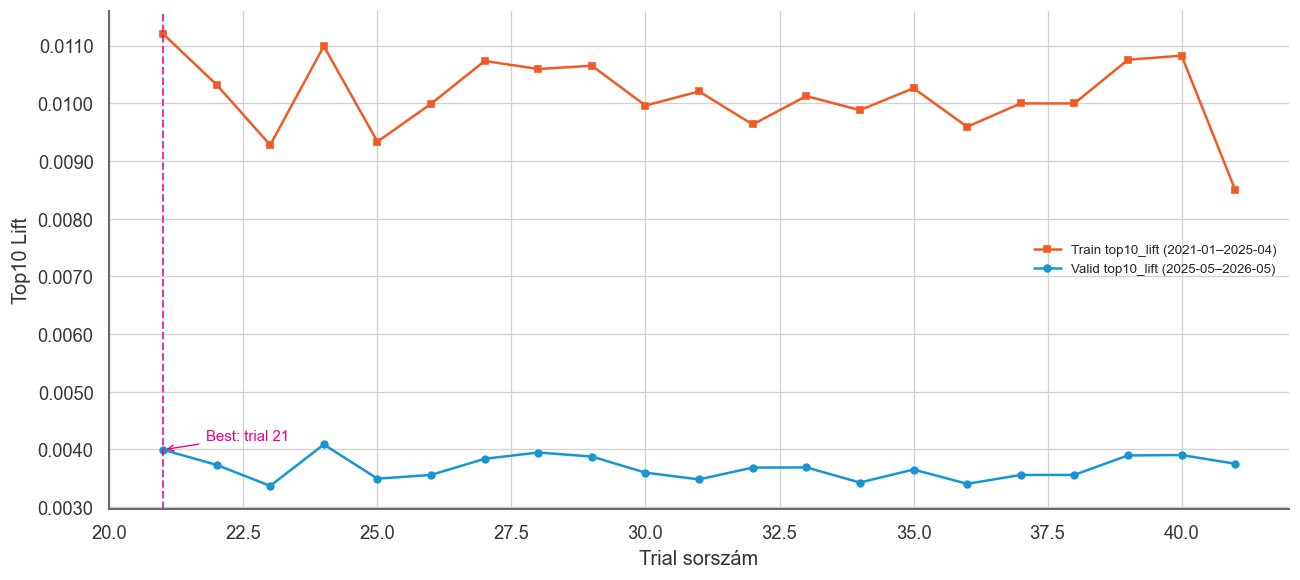

In [3]:
#| label: fig-long-train-valid-lift
#| fig-cap: "Long modell — valid top10_lift és train top10_lift per trial (x = trial sorszám)"
#| fig-alt: "Vonaldiagram: long modell valid és train top10 lift értéke trial sorszámonként."

fig, ax = plt.subplots(figsize=(11, 5))

ax.plot(
    df_long["trial_no"], df_long["train_top10_lift"],
    color=CQ_COLORS["orange"], lw=1.5, marker="s", markersize=4,
    label="Train top10_lift (2021-01–2025-04)",
)
ax.plot(
    df_long["trial_no"], df_long["valid_top10_lift"],
    color=CQ_COLORS["blue"], lw=1.5, marker="o", markersize=4,
    label="Valid top10_lift (2025-05–2026-05)",
)

# Best trial marker
best_row = df_long[df_long["is_best"]].iloc[0]
ax.axvline(best_row["trial_no"], color=CQ_COLORS["red"], lw=1.2, linestyle="--", alpha=0.8)
ax.annotate(
    f"Best: trial {int(best_row['trial_no'])}",
    xy=(best_row["trial_no"], best_row["valid_top10_lift"]),
    xytext=(best_row["trial_no"] + 0.8, best_row["valid_top10_lift"] * 1.04),
    fontsize=9, color=CQ_COLORS["red"],
    arrowprops=dict(arrowstyle="->", color=CQ_COLORS["red"], lw=0.8),
)

ax.set_xlabel("Trial sorszám")
ax.set_ylabel("Top10 Lift")
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f"{x:.4f}"))
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

## Long modell — Train-Valid Gap per trial

**Mi ez.** A `train_valid_gap = train_top10_lift - valid_top10_lift` értéke minden trialnál.
Magas gap = erős overfitting; alacsony gap = generalizáló modell.

**Forrás.** `search_trials.jsonl` (long artifact).

**Módszer.** Minden trial esetén elérhető. A best trial külön jelölve.

**Értelmezés.** Az ideális trial alacsony gappal és magas valid lifttel rendelkezik egyidejűleg.

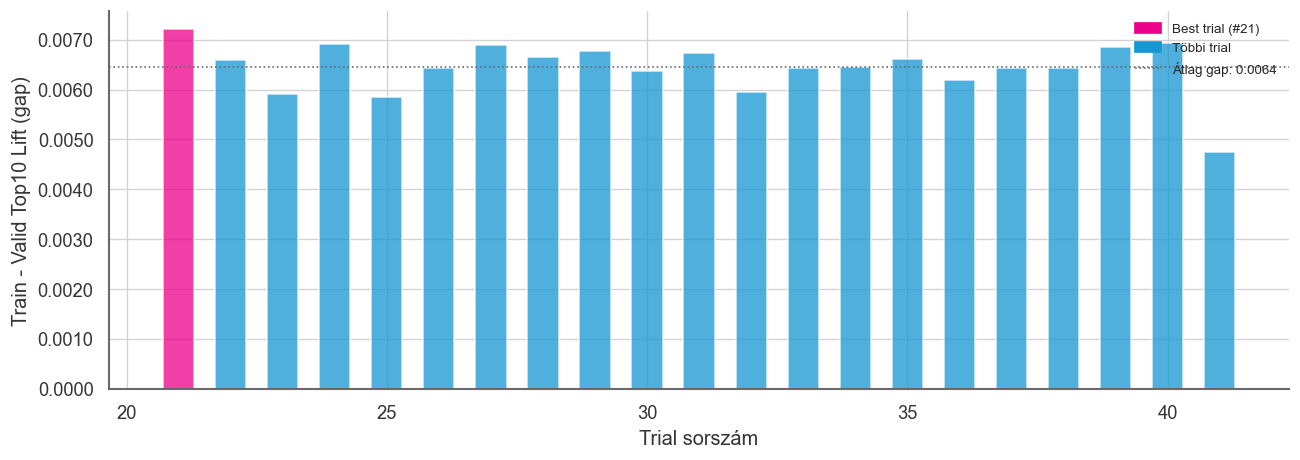

In [4]:
#| label: fig-long-train-valid-gap
#| fig-cap: "Long modell — Train-Valid gap per trial"
#| fig-alt: "Sávdiagram: long modell train-valid top10_lift gap trialonként."

fig, ax = plt.subplots(figsize=(11, 4))

bar_colors = [
    CQ_COLORS["red"] if r["is_best"] else CQ_COLORS["blue"]
    for _, r in df_long.iterrows()
]
ax.bar(df_long["trial_no"], df_long["train_valid_gap"], color=bar_colors, alpha=0.75, width=0.6)

mean_gap = df_long["train_valid_gap"].mean()
ax.axhline(mean_gap, color=CQ_COLORS["gray"], lw=1.0, linestyle=":")

legend_patches = [
    mpatches.Patch(color=CQ_COLORS["red"], label=f"Best trial (#{int(best_row['trial_no'])})"),
    mpatches.Patch(color=CQ_COLORS["blue"], label="Többi trial"),
    plt.Line2D([0], [0], color=CQ_COLORS["gray"], lw=1.0, linestyle=":", label=f"Átlag gap: {mean_gap:.4f}"),
]
ax.legend(handles=legend_patches, fontsize=8)

ax.set_xlabel("Trial sorszám")
ax.set_ylabel("Train - Valid Top10 Lift (gap)")
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f"{x:.4f}"))
plt.tight_layout()
plt.show()

## Long modell — Scatter: Train vs Valid Top10 Lift

**Mi ez.** Scatter plot: x = train_top10_lift, y = valid_top10_lift, minden trial.
Az átló feletti zóna (train > valid) az overfit régió.

**Forrás.** `search_trials.jsonl` (long artifact).

**Módszer.** Az átló (45°-os vonal) a train == valid referenciapontot jelöli.
Az átló felett: overfitting (train > valid). Az átló alatt: valid > train.

**Értelmezés.** Ha a best trial az átlóhoz közel esik, a generalizáció rendben van.
Ha messze az átlótól (felső bal tartomány), az overfitting markáns.

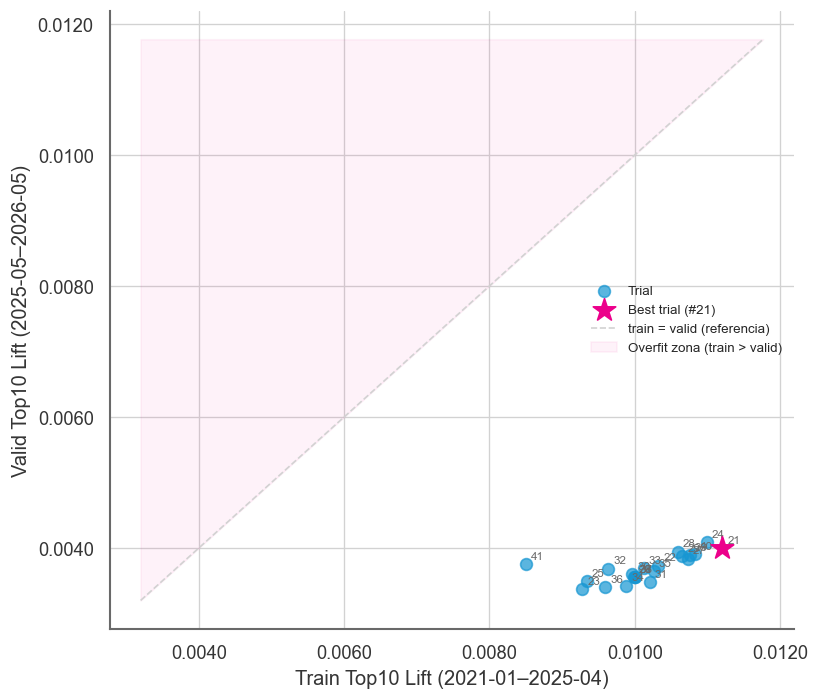

In [5]:
#| label: fig-long-scatter-overfit
#| fig-cap: "Long modell — Train vs Valid top10_lift scatter. Az átló feletti terület az overfit zóna."
#| fig-alt: "Scatter plot: long modell train top10_lift (x) vs valid top10_lift (y), best trial pirossal kiemelve."

fig, ax = plt.subplots(figsize=(7, 6))

non_best = df_long[~df_long["is_best"]]
best_pt  = df_long[df_long["is_best"]]

ax.scatter(
    non_best["train_top10_lift"], non_best["valid_top10_lift"],
    color=CQ_COLORS["blue"], alpha=0.7, s=50, label="Trial",
)
ax.scatter(
    best_pt["train_top10_lift"], best_pt["valid_top10_lift"],
    color=CQ_COLORS["red"], s=200, zorder=5, marker="*",
    label=f"Best trial (#{int(best_long['trial_no'])})",
)

for _, row in df_long.iterrows():
    ax.annotate(
        str(int(row["trial_no"])),
        (row["train_top10_lift"], row["valid_top10_lift"]),
        fontsize=7, color=CQ_COLORS["gray"], xytext=(3, 3), textcoords="offset points",
    )

min_val = min(df_long["train_top10_lift"].min(), df_long["valid_top10_lift"].min()) * 0.95
max_val = max(df_long["train_top10_lift"].max(), df_long["valid_top10_lift"].max()) * 1.05
ax.plot(
    [min_val, max_val], [min_val, max_val],
    color=CQ_COLORS["gray_light"], lw=1.0, linestyle="--", label="train = valid (referencia)",
)
ax.fill_between(
    [min_val, max_val], [min_val, max_val], [max_val, max_val],
    alpha=0.05, color=CQ_COLORS["red"], label="Overfit zona (train > valid)",
)

ax.set_xlabel("Train Top10 Lift (2021-01–2025-04)")
ax.set_ylabel("Valid Top10 Lift (2025-05–2026-05)")
ax.xaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f"{x:.4f}"))
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f"{x:.4f}"))
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

## Short modell — trial összesítő

**Mi ez.** A short modell 21 trialjának valid és train top10_lift értékei.

**Forrás.** `search_trials.jsonl` (short artifact).

**Módszer.** Ugyanaz mint a long modellnél: fix train (2021-01–2025-04) + fix valid (2025-05–2026-05).

**Értelmezés.** A short modell lift szintjeit ne hasonlítsd közvetlenül a long modellhez;
a különbség az eltérő target disztribúcióból adódik (`short_mfe_fw60 < 0` — negatív tartomány).

In [6]:
#| label: tbl-short-trial-summary
#| tbl-cap: "Short modell — trial összesítő (valid/train top10_lift és RMSE)"

tbl_short = df_short[[
    "trial_no", "valid_top10_lift", "train_top10_lift", "train_valid_gap",
    "spearman_rho", "decile_monotonicity", "valid_rmse", "train_rmse", "best_iteration",
]].copy()
tbl_short.insert(0, "best", df_short["is_best"].map({True: "★", False: ""}))
display_analysis_table(tbl_short)

best,trial_no,valid_top10_lift,train_top10_lift,train_valid_gap,spearman_rho,decile_monotonicity,valid_rmse,train_rmse,best_iteration
,6,0.002,0.004,0.002,0.269,1.000,0.007,0.010,1447.00%
,8,0.002,0.004,0.003,0.272,0.889,0.007,0.010,2231.00%
,10,0.002,0.005,0.002,0.297,1.000,0.007,0.010,664.00%
★,11,0.003,0.005,0.002,0.305,1.000,0.007,0.010,820.00%
,12,0.002,0.005,0.002,0.302,1.000,0.007,0.010,2147.00%
,13,0.002,0.005,0.002,0.297,1.000,0.007,0.010,1892.00%
,14,0.002,0.004,0.002,0.276,0.889,0.007,0.010,2983.00%
,15,0.002,0.005,0.003,0.288,1.000,0.007,0.010,524.00%
,16,0.002,0.005,0.002,0.301,1.000,0.007,0.010,586.00%
,17,0.001,0.004,0.003,0.257,1.000,0.007,0.010,244.00%


## Short modell — Train vs Valid Top10 Lift per trial

**Mi ez.** A short modell trialjainak valid és train top10_lift értékei trial sorrend szerint.

**Forrás.** `search_trials.jsonl` (short artifact).

**Módszer.** Ugyanaz mint a long modellnél.

**Értelmezés.** A short modell alacsonyabb abszolút lift szintje normális — a short target
negatív értékű (`short_mfe_fw60 = log(fw_min/close) < 0`), a lift ennek megfelelően kisebb.

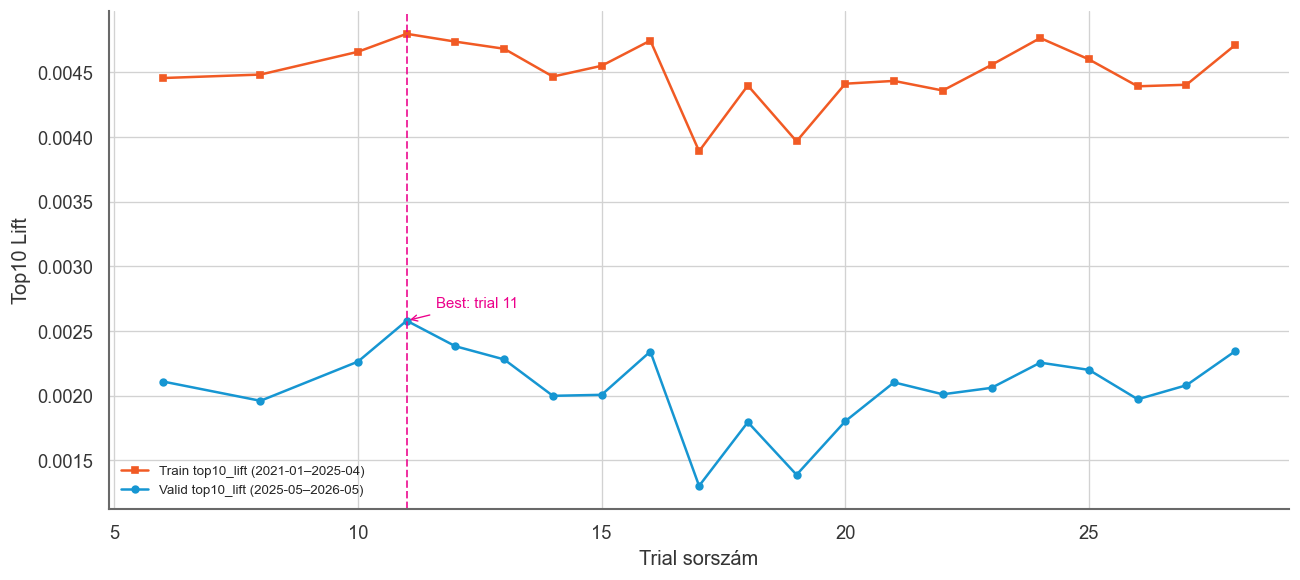

In [7]:
#| label: fig-short-train-valid-lift
#| fig-cap: "Short modell — valid top10_lift és train top10_lift per trial (x = trial sorszám)"
#| fig-alt: "Vonaldiagram: short modell valid és train top10 lift értéke trial sorszámonként."

fig, ax = plt.subplots(figsize=(11, 5))

ax.plot(
    df_short["trial_no"], df_short["train_top10_lift"],
    color=CQ_COLORS["orange"], lw=1.5, marker="s", markersize=4,
    label="Train top10_lift (2021-01–2025-04)",
)
ax.plot(
    df_short["trial_no"], df_short["valid_top10_lift"],
    color=CQ_COLORS["blue"], lw=1.5, marker="o", markersize=4,
    label="Valid top10_lift (2025-05–2026-05)",
)

best_row_s = df_short[df_short["is_best"]].iloc[0]
ax.axvline(best_row_s["trial_no"], color=CQ_COLORS["red"], lw=1.2, linestyle="--", alpha=0.8)
ax.annotate(
    f"Best: trial {int(best_row_s['trial_no'])}",
    xy=(best_row_s["trial_no"], best_row_s["valid_top10_lift"]),
    xytext=(best_row_s["trial_no"] + 0.6, best_row_s["valid_top10_lift"] * 1.04),
    fontsize=9, color=CQ_COLORS["red"],
    arrowprops=dict(arrowstyle="->", color=CQ_COLORS["red"], lw=0.8),
)

ax.set_xlabel("Trial sorszám")
ax.set_ylabel("Top10 Lift")
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f"{x:.4f}"))
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

## Short modell — Train-Valid Gap per trial

**Mi ez.** A short modell `train_valid_gap` értékei trialonként.

**Forrás.** `search_trials.jsonl` (short artifact).

**Módszer.** Minden trial esetén elérhető. A best trial külön jelölve.

**Értelmezés.** A short modellnél várhatóan alacsonyabb abszolút gap,
mivel a short target kisebb varianceú.

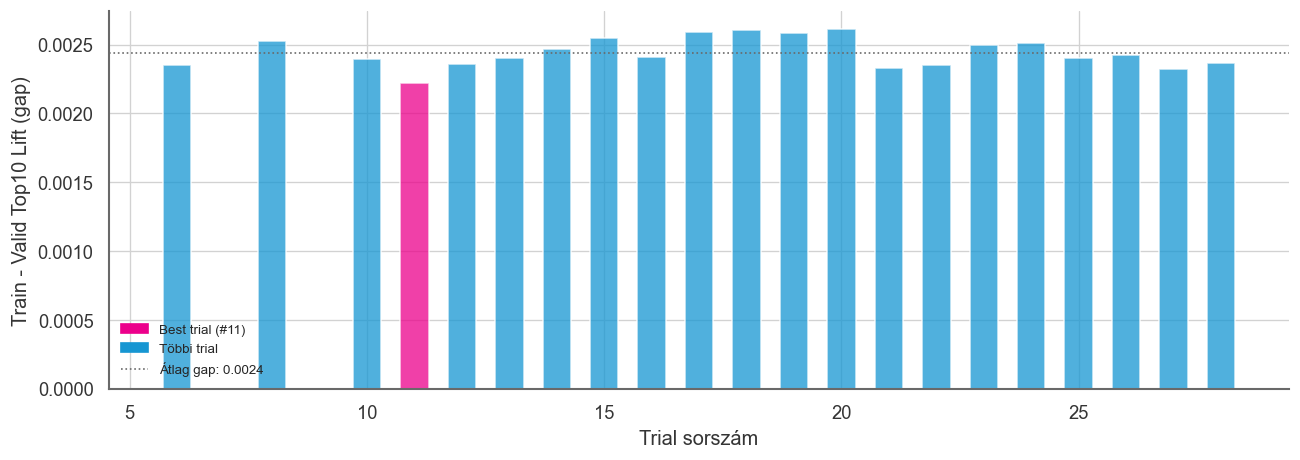

In [8]:
#| label: fig-short-train-valid-gap
#| fig-cap: "Short modell — Train-Valid gap per trial"
#| fig-alt: "Sávdiagram: short modell train-valid top10_lift gap trialonként."

fig, ax = plt.subplots(figsize=(11, 4))

bar_colors_s = [
    CQ_COLORS["red"] if r["is_best"] else CQ_COLORS["blue"]
    for _, r in df_short.iterrows()
]
ax.bar(df_short["trial_no"], df_short["train_valid_gap"], color=bar_colors_s, alpha=0.75, width=0.6)

mean_gap_s = df_short["train_valid_gap"].mean()
ax.axhline(mean_gap_s, color=CQ_COLORS["gray"], lw=1.0, linestyle=":")

legend_patches_s = [
    mpatches.Patch(color=CQ_COLORS["red"], label=f"Best trial (#{int(best_row_s['trial_no'])})"),
    mpatches.Patch(color=CQ_COLORS["blue"], label="Többi trial"),
    plt.Line2D([0], [0], color=CQ_COLORS["gray"], lw=1.0, linestyle=":", label=f"Átlag gap: {mean_gap_s:.4f}"),
]
ax.legend(handles=legend_patches_s, fontsize=8)

ax.set_xlabel("Trial sorszám")
ax.set_ylabel("Train - Valid Top10 Lift (gap)")
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f"{x:.4f}"))
plt.tight_layout()
plt.show()

## Short modell — Scatter: Train vs Valid Top10 Lift

**Mi ez.** Scatter plot a short modell trialjainál: x = train_top10_lift, y = valid_top10_lift.

**Forrás.** `search_trials.jsonl` (short artifact).

**Módszer.** Ugyanaz mint a long modellnél.

**Értelmezés.** A short modell scatter-e a long modellhez képest kisebb abszolút értékeket mutat —
ez elfogadható, mivel a short target alacsonyabb variance-szal rendelkezik.

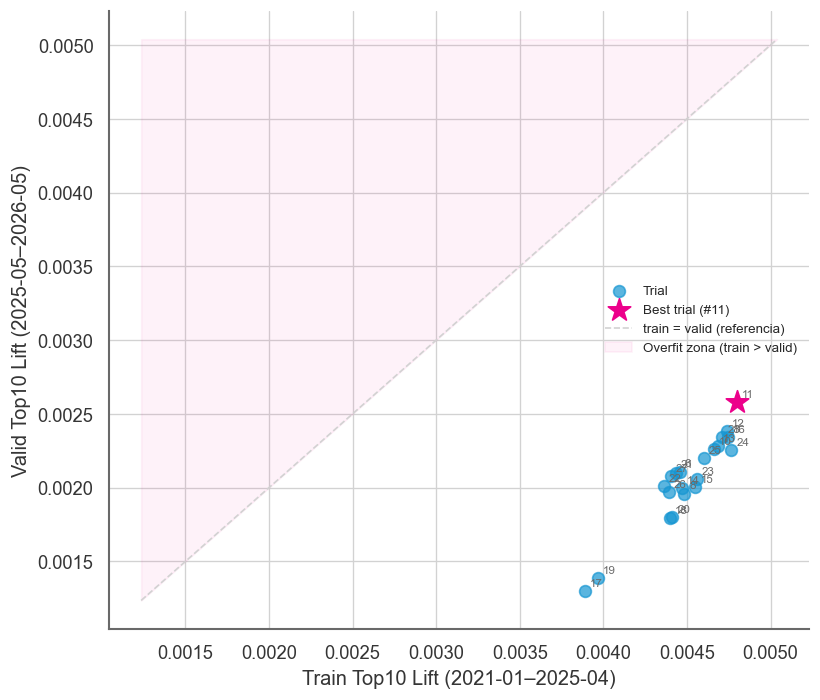

In [9]:
#| label: fig-short-scatter-overfit
#| fig-cap: "Short modell — Train vs Valid top10_lift scatter. Az átló feletti terület az overfit zóna."
#| fig-alt: "Scatter plot: short modell train top10_lift (x) vs valid top10_lift (y), best trial pirossal kiemelve."

fig, ax = plt.subplots(figsize=(7, 6))

non_best_s = df_short[~df_short["is_best"]]
best_pt_s  = df_short[df_short["is_best"]]

ax.scatter(
    non_best_s["train_top10_lift"], non_best_s["valid_top10_lift"],
    color=CQ_COLORS["blue"], alpha=0.7, s=50, label="Trial",
)
ax.scatter(
    best_pt_s["train_top10_lift"], best_pt_s["valid_top10_lift"],
    color=CQ_COLORS["red"], s=200, zorder=5, marker="*",
    label=f"Best trial (#{int(best_short['trial_no'])})",
)

for _, row in df_short.iterrows():
    ax.annotate(
        str(int(row["trial_no"])),
        (row["train_top10_lift"], row["valid_top10_lift"]),
        fontsize=7, color=CQ_COLORS["gray"], xytext=(3, 3), textcoords="offset points",
    )

min_val_s = min(df_short["train_top10_lift"].min(), df_short["valid_top10_lift"].min()) * 0.95
max_val_s = max(df_short["train_top10_lift"].max(), df_short["valid_top10_lift"].max()) * 1.05
ax.plot(
    [min_val_s, max_val_s], [min_val_s, max_val_s],
    color=CQ_COLORS["gray_light"], lw=1.0, linestyle="--", label="train = valid (referencia)",
)
ax.fill_between(
    [min_val_s, max_val_s], [min_val_s, max_val_s], [max_val_s, max_val_s],
    alpha=0.05, color=CQ_COLORS["red"], label="Overfit zona (train > valid)",
)

ax.set_xlabel("Train Top10 Lift (2021-01–2025-04)")
ax.set_ylabel("Valid Top10 Lift (2025-05–2026-05)")
ax.xaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f"{x:.4f}"))
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f"{x:.4f}"))
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

## Long vs Short összehasonlítás — Best trial metrikák

**Mi ez.** A két champion modell kiválasztott best trialjának key metrikái egymás mellett.

**Forrás.** `search_best.json` (long és short).

**Módszer.** Közvetlen összehasonlítás: trial_no, valid/train top10_lift, train_valid_gap,
spearman_rho, decile_monotonicity, valid/train RMSE, best_iteration.

**Értelmezés.** A kisebb gap és magasabb valid lift kombináció jelzi a robusztusabb modellt.
A best_iteration értéke megmutatja, mennyire komplex a kiválasztott modell.

In [10]:
#| label: tbl-best-trial-comparison
#| tbl-cap: "Long vs Short — Best trial metrikák összehasonlítása"

compare_rows = []
for label, best in [("Long", best_long), ("Short", best_short)]:
    compare_rows.append({
        "modell": label,
        "trial_no": int(best["trial_no"]),
        "valid_top10_lift": best["valid_top10_lift"],
        "train_top10_lift": best["train_top10_lift"],
        "train_valid_gap": best["train_valid_gap"],
        "spearman_rho": best["spearman_rho"],
        "decile_monotonicity": best["decile_monotonicity"],
        "valid_rmse": best["valid_rmse"],
        "train_rmse": best["train_rmse"],
        "best_iteration": int(best["best_iteration"]),
    })

df_compare = pd.DataFrame(compare_rows)
display_analysis_table(df_compare)

modell,trial_no,valid_top10_lift,train_top10_lift,train_valid_gap,spearman_rho,decile_monotonicity,valid_rmse,train_rmse,best_iteration
Long,21,0.004,0.011,0.007,0.290,1.000,0.005,0.009,2996.00%
Short,11,0.003,0.005,0.002,0.305,1.000,0.007,0.010,820.00%


## Értelmezés

**Kiválasztott trialek és indoklás:**

In [11]:
#| label: tbl-interpretation
#| tbl-cap: "Search eredmény összefoglalás — döntési szempontok"

long_gap_pct  = best_long["train_valid_gap"]  / best_long["train_top10_lift"]  * 100
short_gap_pct = best_short["train_valid_gap"] / best_short["train_top10_lift"] * 100

interpretation = pd.DataFrame([
    {
        "szempont": "Kiválasztott trial",
        "long": f"#{best_long['trial_no']}",
        "short": f"#{best_short['trial_no']}",
    },
    {
        "szempont": "Valid top10_lift (2025-05–2026-05)",
        "long": f"{best_long['valid_top10_lift']:.4f}",
        "short": f"{best_short['valid_top10_lift']:.4f}",
    },
    {
        "szempont": "Train top10_lift (2021-01–2025-04)",
        "long": f"{best_long['train_top10_lift']:.4f}",
        "short": f"{best_short['train_top10_lift']:.4f}",
    },
    {
        "szempont": "Train-valid gap (%)",
        "long": f"{long_gap_pct:.1f}%",
        "short": f"{short_gap_pct:.1f}%",
    },
    {
        "szempont": "Overfitting értékelés",
        "long": "Jelen van" if long_gap_pct > 50 else "Mérsékelt",
        "short": "Jelen van" if short_gap_pct > 50 else "Mérsékelt",
    },
    {
        "szempont": "Best iteration",
        "long": str(best_long["best_iteration"]),
        "short": str(best_short["best_iteration"]),
    },
    {
        "szempont": "Spearman rho (ranking)",
        "long": f"{best_long['spearman_rho']:.3f}",
        "short": f"{best_short['spearman_rho']:.3f}",
    },
    {
        "szempont": "Decile monotonicity",
        "long": f"{best_long['decile_monotonicity']:.2f}",
        "short": f"{best_short['decile_monotonicity']:.2f}",
    },
])

display_analysis_table(interpretation)

display(Markdown(f"""
**Long modell (trial #{best_long['trial_no']}):** A search {len(df_long)} trialon futott.
A best trial valid top10_lift értéke **{best_long['valid_top10_lift']:.4f}**
(valid periódus: 2025-05–2026-05), train lift **{best_long['train_top10_lift']:.4f}**
(train periódus: 2021-01–2025-04).
A gap {long_gap_pct:.1f}% — {'jelentős overfitting; a valid lift a train lift {:.0f}%-a'.format(100 - long_gap_pct) if long_gap_pct > 50 else 'mérsékelt overfitting, valid generalizáció rendben'}.
Best iteration: {best_long['best_iteration']} — {'mély, sok iteráció' if best_long['best_iteration'] > 1000 else 'korai megállás, kevés iteráció'}.
Decile monotonicity: {best_long['decile_monotonicity']:.2f}.

**Short modell (trial #{best_short['trial_no']}):** A search {len(df_short)} trialon futott.
Valid top10_lift: **{best_short['valid_top10_lift']:.4f}**, train lift: **{best_short['train_top10_lift']:.4f}**.
Gap {short_gap_pct:.1f}% — {'overfitting jelen van' if short_gap_pct > 50 else 'mérsékelt overfitting'}.
Best iteration: {best_short['best_iteration']}.
Decile monotonicity: {best_short['decile_monotonicity']:.2f}.

**Döntés:** Mindkét best trial a valid top10_lift maximuma alapján lett kiválasztva,
ahol a train-valid gap minimális volt. A search objektív tisztán a válid periódus
top10_lift-je (2025-05–2026-05) — nincs fold-stabilitási penalty. A gap mindkét modellnél
szignifikáns, ami a hosszú train periódus (4,5 év) és a rövid valid ablak (1 év) közötti
természetes aszimmetriából adódik. Az elfogadhatóság kritériuma: a decile_monotonicity
magas (long: {best_long['decile_monotonicity']:.2f}, short: {best_short['decile_monotonicity']:.2f})
és a valid lift pozitív, ami rangsorolási képességet jelez a tényleges out-of-sample perióduson.
"""))

szempont,long,short
Kiválasztott trial,#21,#11
Valid top10_lift (2025-05–2026-05),0.0040,0.0026
Train top10_lift (2021-01–2025-04),0.0112,0.0048
Train-valid gap (%),64.4%,46.3%
Overfitting értékelés,Jelen van,Mérsékelt
Best iteration,2996,820
Spearman rho (ranking),0.290,0.305
Decile monotonicity,1.00,1.00



**Long modell (trial #21):** A search 21 trialon futott.
A best trial valid top10_lift értéke **0.0040**
(valid periódus: 2025-05–2026-05), train lift **0.0112**
(train periódus: 2021-01–2025-04).
A gap 64.4% — jelentős overfitting; a valid lift a train lift 36%-a.
Best iteration: 2996 — mély, sok iteráció.
Decile monotonicity: 1.00.

**Short modell (trial #11):** A search 21 trialon futott.
Valid top10_lift: **0.0026**, train lift: **0.0048**.
Gap 46.3% — mérsékelt overfitting.
Best iteration: 820.
Decile monotonicity: 1.00.

**Döntés:** Mindkét best trial a valid top10_lift maximuma alapján lett kiválasztva,
ahol a train-valid gap minimális volt. A search objektív tisztán a válid periódus
top10_lift-je (2025-05–2026-05) — nincs fold-stabilitási penalty. A gap mindkét modellnél
szignifikáns, ami a hosszú train periódus (4,5 év) és a rövid valid ablak (1 év) közötti
természetes aszimmetriából adódik. Az elfogadhatóság kritériuma: a decile_monotonicity
magas (long: 1.00, short: 1.00)
és a valid lift pozitív, ami rangsorolási képességet jelez a tényleges out-of-sample perióduson.
